In [10]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

In [2]:
image = cv2.imread("image.jpg")

if image is None:
    print("Error: Image not found!")
    exit()

# 1. Convert Image to Grayscale

Grayscale conversion transforms a color image into a single-channel image by removing color information while preserving brightness.

### Explanation

- `cv2.cvtColor()` converts an image from one color space to another.
- The `cv2.COLOR_BGR2GRAY` conversion changes a BGR image into a grayscale image.
- Each pixel in the grayscale image represents only intensity values ranging from **0 (black)** to **255 (white)**.
- Grayscale images simplify image processing and reduce computational complexity.

Grayscale Image


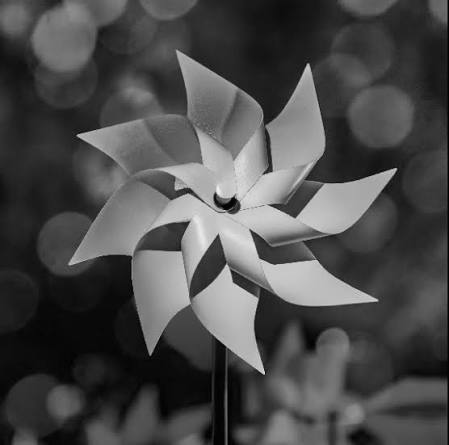

In [11]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
print("Grayscale Image")
cv2_imshow(gray)

# 2. Apply Gaussian Blur

Gaussian Blur smooths the image by reducing noise and fine details. It is commonly applied before edge detection to improve the quality of detected edges.

### Explanation

- `cv2.GaussianBlur()` applies a Gaussian filter to the image.
- The kernel size `(5,5)` determines the area used for smoothing.
- The sigma value of `0` allows OpenCV to calculate the optimal standard deviation automatically.
- Blurring reduces unwanted noise that could otherwise produce false edges.

Gaussian Blurred Image


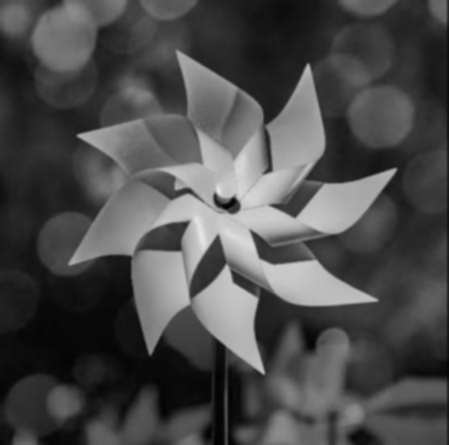

In [12]:
blur = cv2.GaussianBlur(gray, (5,5), 0)
print("Gaussian Blurred Image")
cv2_imshow(blur)

# 3. Sobel Edge Detection

The Sobel Operator detects edges by calculating the intensity gradient in both the horizontal and vertical directions.

### Explanation

- The horizontal Sobel filter detects vertical edges.
- The vertical Sobel filter detects horizontal edges.
- Both gradient images are combined to produce the final edge image.
- The resulting gradient values are converted into an 8-bit image for visualization.
- Sobel provides information about both edge strength and edge direction.

Sobel Edge Detection


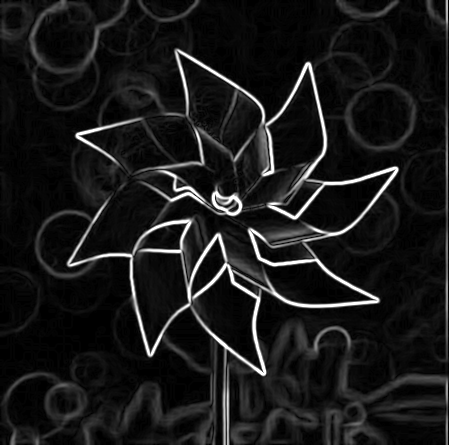

In [13]:
sobel_x = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sobel_x, sobel_y)
sobel = cv2.convertScaleAbs(sobel)
print("Sobel Edge Detection")
cv2_imshow(sobel)

# 4. Laplacian Edge Detection

The Laplacian Operator detects edges by calculating the second derivative of image intensity.

### Explanation

- The Laplacian detects edges in all directions simultaneously.
- It highlights regions where the intensity changes rapidly.
- Since the output contains floating-point values, it is converted into an 8-bit image before displaying.
- Laplacian is more sensitive to noise than Sobel, so Gaussian Blur is usually applied beforehand.

Laplacian Edge Detection


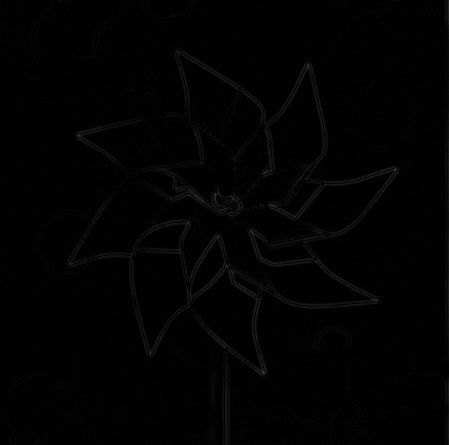

In [14]:
laplacian = cv2.Laplacian(blur, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)
print("Laplacian Edge Detection")
cv2_imshow(laplacian)

# 5. Canny Edge Detection

Canny Edge Detection is a multi-stage algorithm that produces accurate and thin edges while minimizing noise.

### Explanation

- The lower threshold determines weak edges.
- The upper threshold determines strong edges.
- Weak edges connected to strong edges are preserved, while isolated weak edges are removed.
- Canny provides cleaner and more continuous edge detection compared to Sobel and Laplacian.

Canny Edge Detection


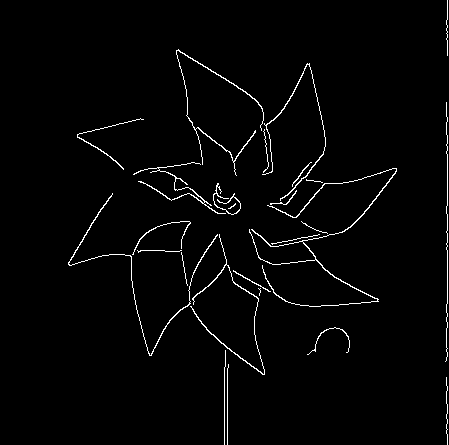

In [15]:
canny = cv2.Canny(blur, 50, 150)
print("Canny Edge Detection")
cv2_imshow(canny)

# 6. Compare Edge Detection Methods

Comparing the outputs of Sobel, Laplacian, and Canny side by side makes it easier to understand their differences.

### Explanation

- `np.hstack()` combines multiple images horizontally.
- The resulting image displays all edge detection methods in a single view.
- This comparison helps evaluate which technique works best for a particular image.

Sobel | Laplacian | Canny


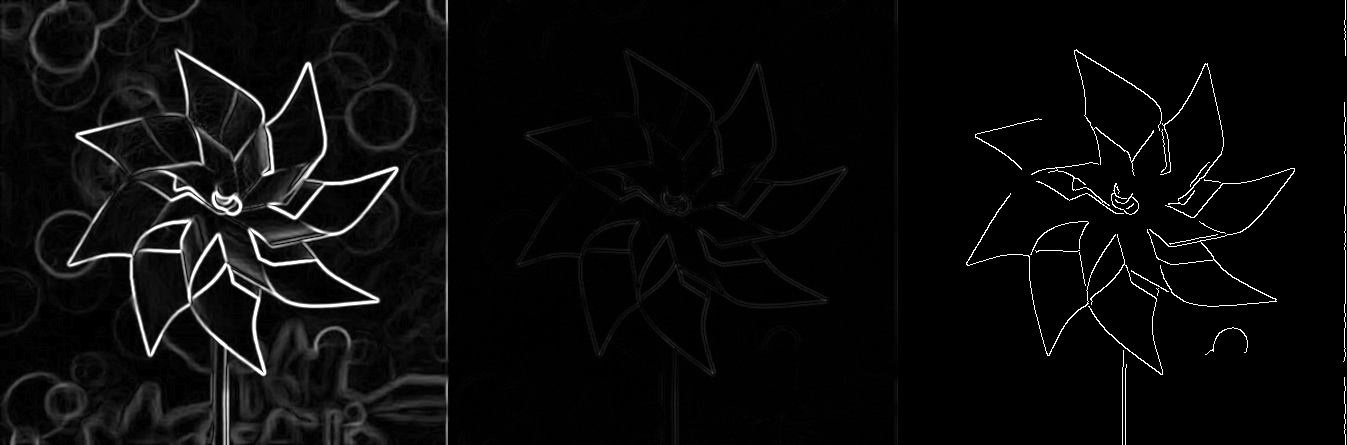

In [16]:
comparison = np.hstack((sobel, laplacian, canny))
print("Sobel | Laplacian | Canny")
cv2_imshow(comparison)

# 7. Create a Morphological Kernel

Morphological operations require a structuring element called a kernel.

### Explanation

- `np.ones()` creates a matrix filled with ones.
- The kernel size `(5,5)` defines the neighborhood used during morphological processing.
- The kernel determines how surrounding pixels influence each operation.

In [17]:
kernel = np.ones((5,5), np.uint8)

# 8. Erosion

Erosion removes pixels from the boundaries of foreground objects, causing them to shrink.

### Explanation

- White regions become smaller.
- Small white noise is removed from the image.
- Thin connections between objects may disappear.
- Erosion is useful for separating touching objects and eliminating unwanted foreground pixels.

Erosion


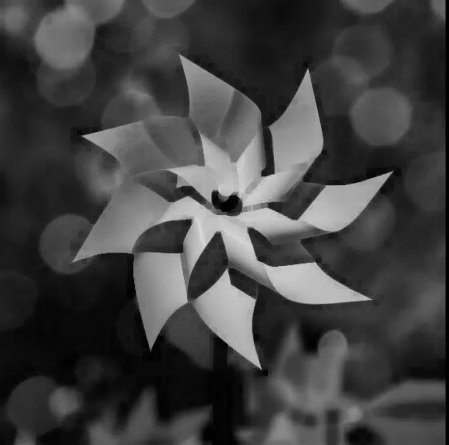

In [18]:
erosion = cv2.erode(gray, kernel, iterations=1)
print("Erosion")
cv2_imshow(erosion)

# 9. Dilation

Dilation adds pixels to the boundaries of foreground objects, causing them to grow.

### Explanation

- White regions become larger.
- Small holes inside objects are filled.
- Nearby objects may become connected.
- Dilation is commonly used after erosion to restore object size.

Dilation


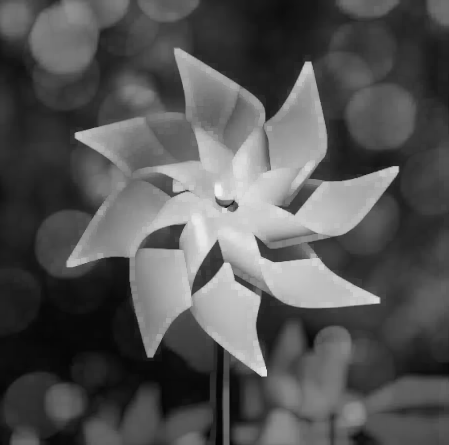

In [19]:
dilation = cv2.dilate(gray, kernel, iterations=1)
print("Dilation")
cv2_imshow(dilation)

# 10. Opening

Opening is a combination of erosion followed by dilation.

### Explanation

- Small white noise is removed.
- The main object is preserved.
- Object boundaries become smoother.
- Opening is frequently used as a preprocessing step before segmentation and OCR.

Opening


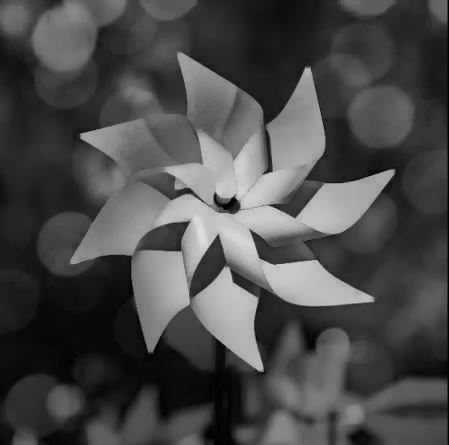

In [23]:
opening = cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel)
print("Opening")
cv2_imshow(opening)

# 11. Closing

Closing is a combination of dilation followed by erosion.

### Explanation

- Small holes inside foreground objects are filled.
- Broken object boundaries are connected.
- Small gaps disappear while preserving the overall object shape.
- Closing is widely used in document enhancement and object segmentation.

Closing


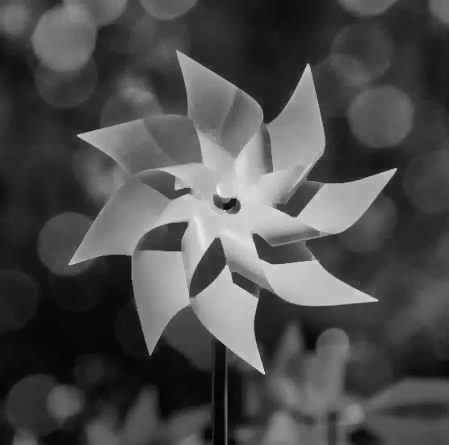

In [24]:
closing = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, kernel)
print("Closing")
cv2_imshow(closing)

# 12. Morphological Gradient

The Morphological Gradient extracts the outlines of objects.

### Explanation

- It is calculated as the difference between the dilated and eroded images.
- Only the object boundaries remain visible.
- It is useful for contour detection and boundary extraction.

Morphological Gradient


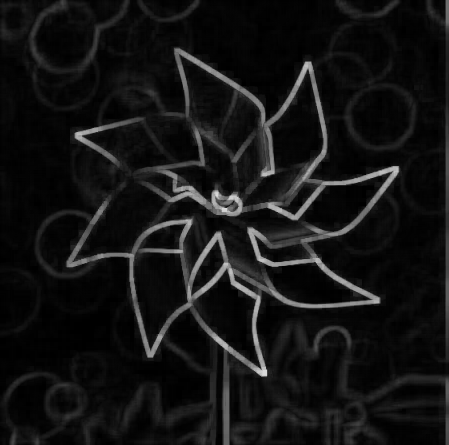

In [25]:
gradient = cv2.morphologyEx(gray, cv2.MORPH_GRADIENT, kernel)
print("Morphological Gradient")
cv2_imshow(gradient)

# 13. Top Hat Transformation

The Top Hat transformation extracts small bright objects from the image.

### Explanation

- It computes the difference between the original image and its opened version.
- Bright spots and fine details become more visible.
- It is useful for detecting bright defects, small objects, and thin structures.

Top Hat


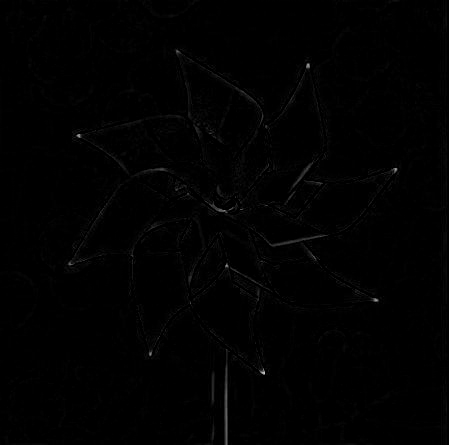

In [26]:
top_hat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel)
print("Top Hat")
cv2_imshow(top_hat)

# 14. Black Hat Transformation

The Black Hat transformation extracts small dark objects from a bright background.

### Explanation

- It computes the difference between the closed image and the original image.
- Dark spots, cracks, and small holes become more visible.
- It is commonly used in defect detection and document enhancement.

Black Hat


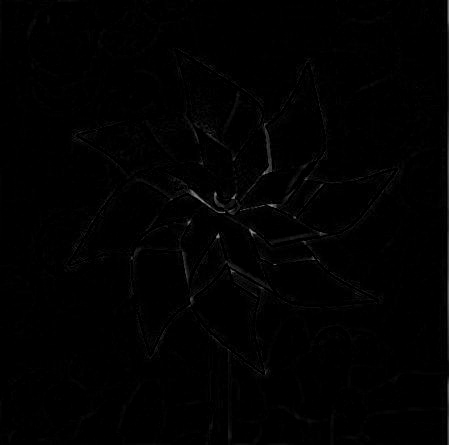

In [27]:
black_hat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
print("Black Hat")
cv2_imshow(black_hat)

Gray | Erosion | Dilation | Opening | Closing | Gradient | Top Hat | Black Hat


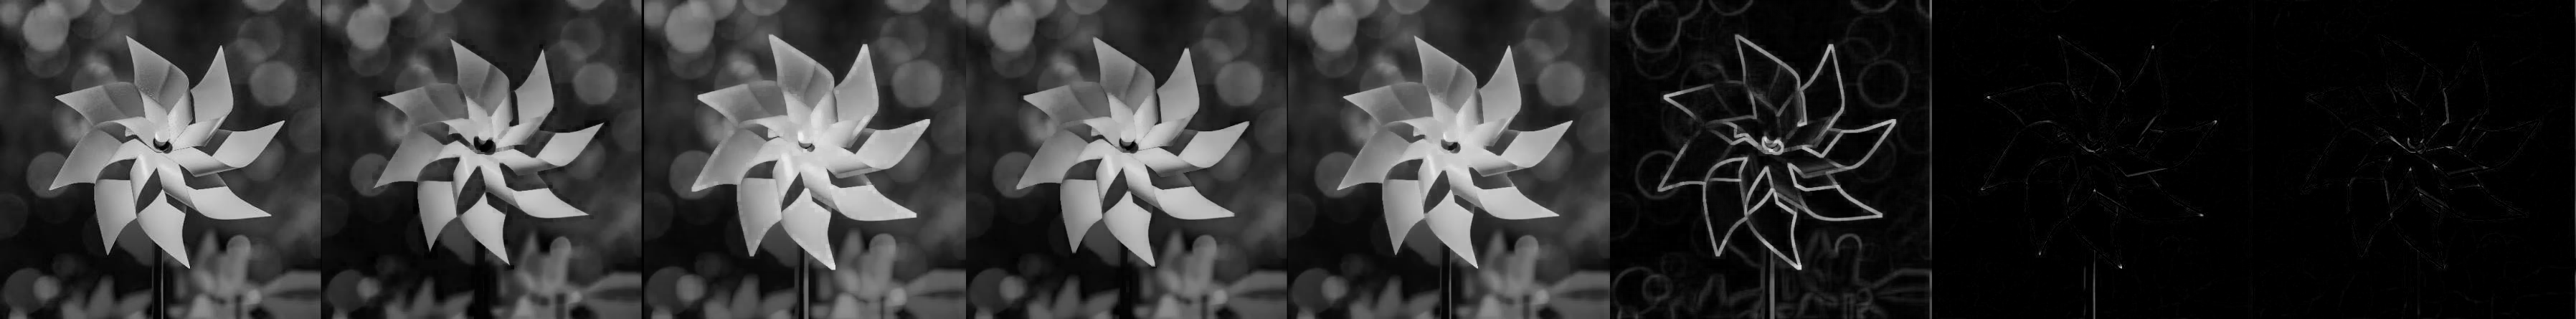

In [28]:
comparison = np.hstack((gray,erosion,dilation,opening,closing,gradient,top_hat,black_hat))
print("Gray | Erosion | Dilation | Opening | Closing | Gradient | Top Hat | Black Hat")
cv2_imshow(comparison)